# From one sentence to reusable plotting code

Create and refine charts from two sample datasets, then inspect, replay, and reuse the generated Python.

**Setup:** Follow the [README quick start](../README.md#quick-start), select the Augplot kernel, and enter your API key when prompted; the first dataset load needs internet access.

**Note:** Your provider receives a data profile, and generated Python runs locally without a security sandbox.


In [1]:
import os
from getpass import getpass

os.environ["AUGPLOT_MODEL"] = "openai/gpt-6-sol"
os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")

import augplot as ap

## 1. Ask for a useful first view

Load the penguins dataset and ask Augplot to compare bill measurements across species.


Augplot: plotting... attempt 1/2
Augplot: checking generated plotting code...


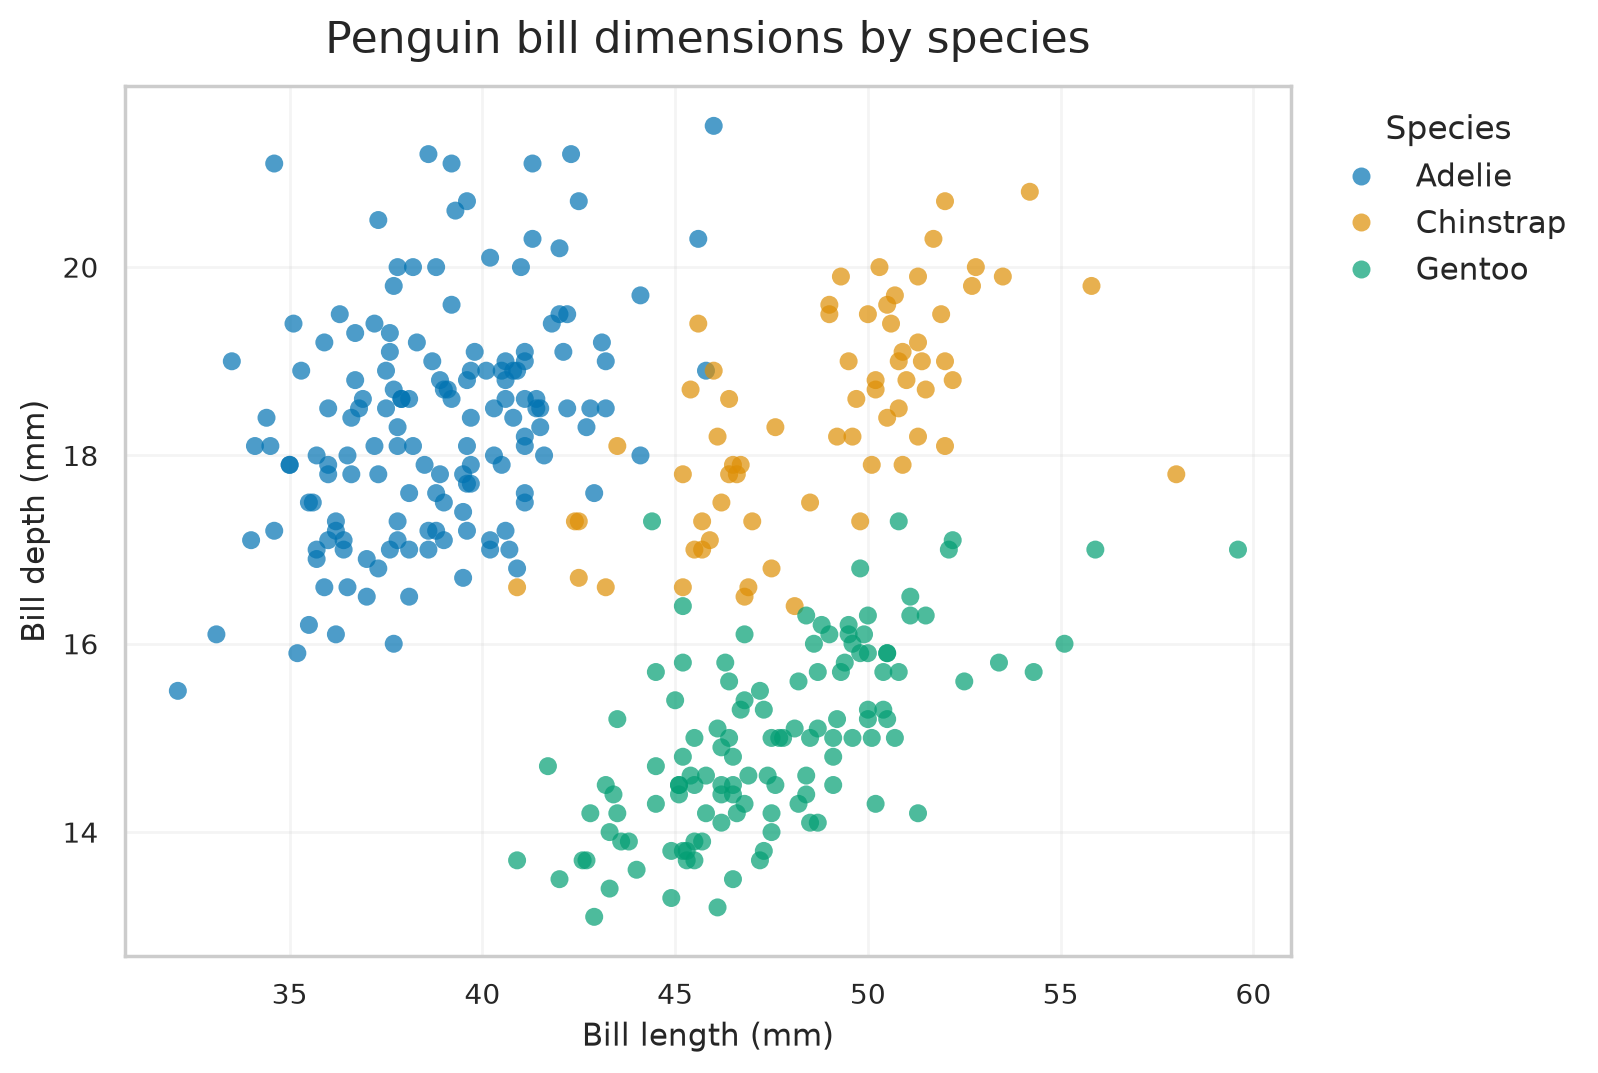

In [2]:
penguin_prompt = "Compare bill length and depth across penguin species."
penguins = ap.load_sns_dataset("penguins")
plt = ap.plot(
    penguins,
    backend="seaborn",
    prompt=penguin_prompt,
)

In [3]:
print(plt.explanation)
print("Reused saved code:", plt.cache_hit)

A scatter plot compares bill length and depth for individual penguins, colored by species. Rows missing either measurement or species are omitted; no aggregation is applied.
Reused saved code: False


## 2. Refine the instruction, not the plotting code

Refine the penguin chart with one panel and trend line per species, shared axes, and marker shapes for sex.


Augplot: plotting... attempt 1/2
Augplot: still waiting for the model (attempt 1/2)...
Augplot: checking generated plotting code...


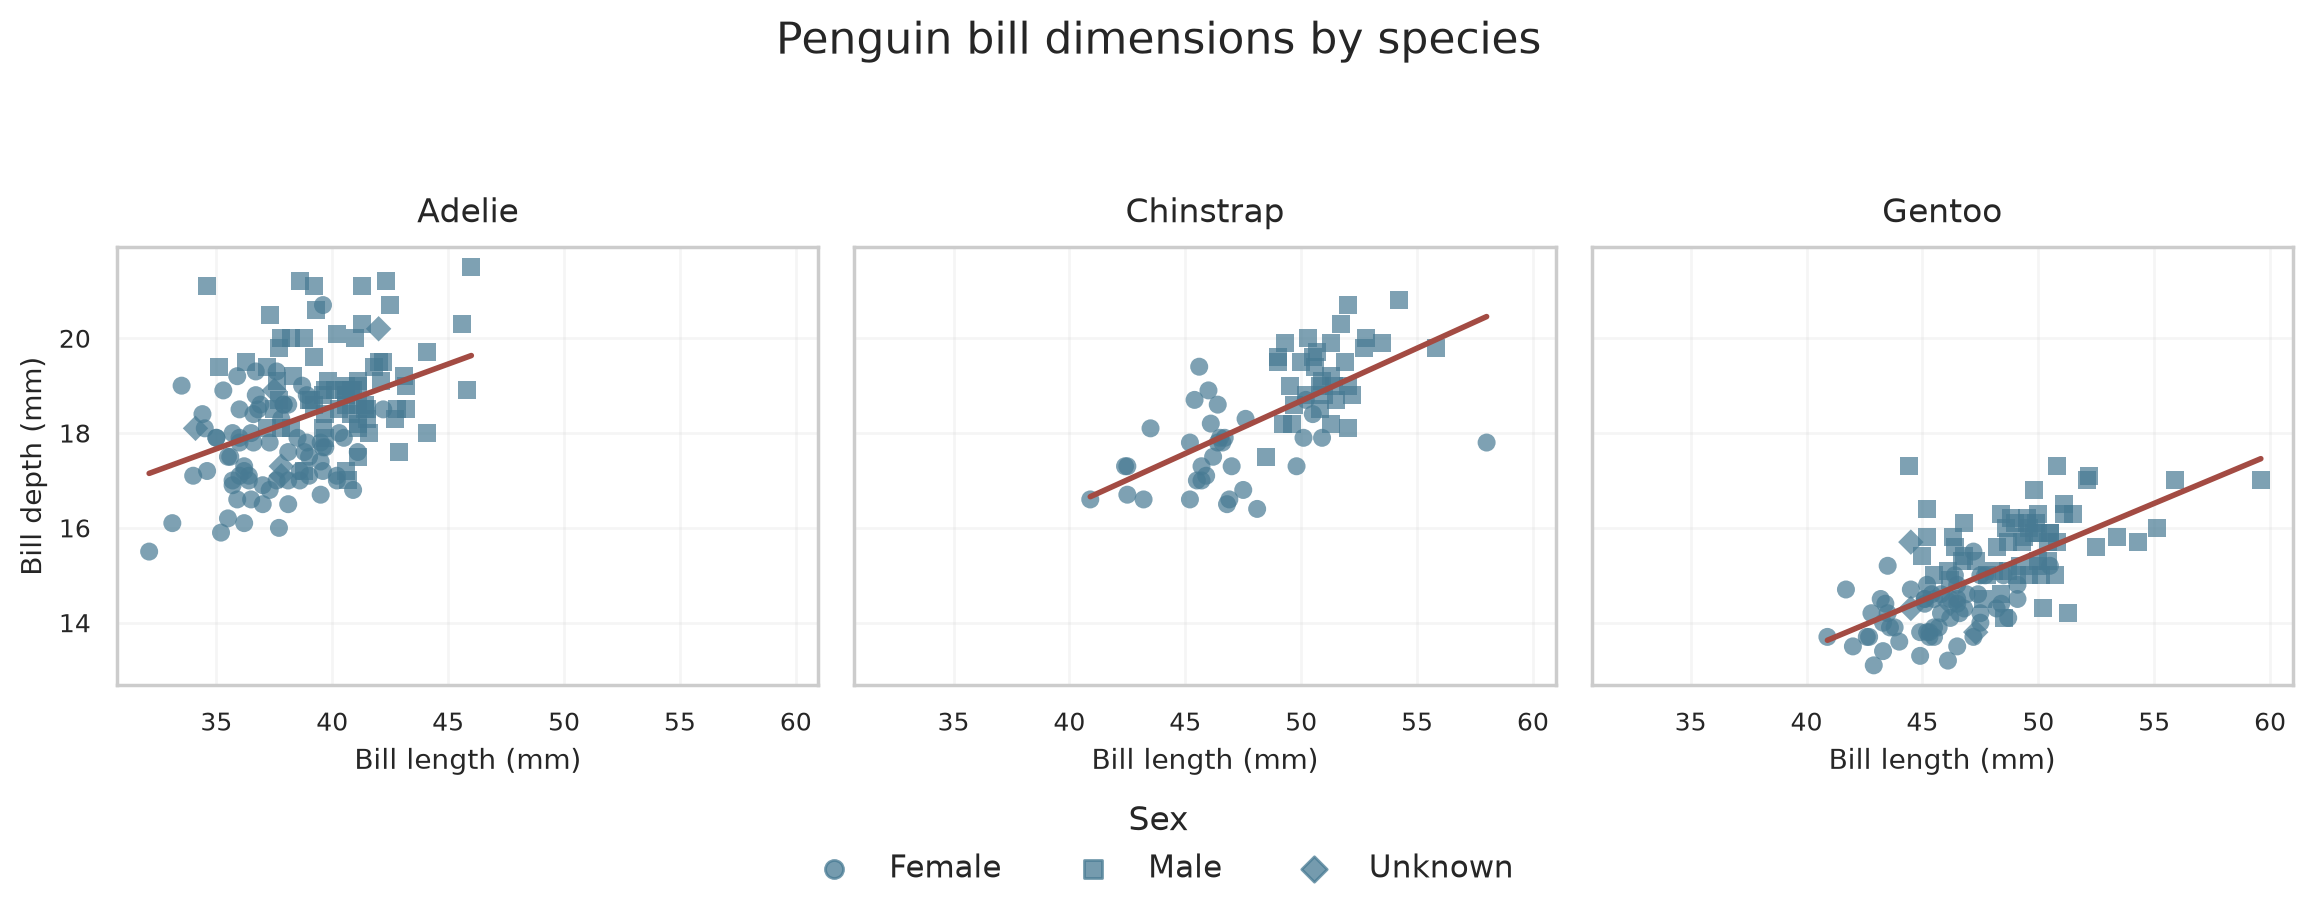

Augplot(backend='seaborn', state='fitted')

In [4]:
penguin_refinement = (
    "Use one panel per species with shared axes, add a Seaborn regression trend "
    "as a visual summary in each panel, and keep sex visible with marker shape."
)
plt.refine(penguin_refinement)

## 3. Inspect what one sentence produced

Inspect the generated plotting function in `plt.code`.


In [5]:
# Summarize the result, then display the generated function.
from IPython.display import Code

line_count = len(plt.code.strip().splitlines())
source_origin = "a history replay" if plt.cache_hit else "one refinement sentence"
print(
    f"Result of {source_origin}: a {line_count}-line reusable Python function."
)
print(
    "It coordinates faceting, shared axes, sex encoding, per-panel trends, "
    "labels, legends, and layout."
)
print("Saved history file:", plt.history_path.name if plt.history_path else "none")
Code(plt.code, language="python")

Result of one refinement sentence: a 54-line reusable Python function.
It coordinates faceting, shared axes, sex encoding, per-panel trends, labels, legends, and layout.
Saved history file: refined_1_2741e80aa03e4a6c9bcee5a89494d5ec.py


def plot_data(data, *, title=None, figsize=None):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    df = data.copy()
    df['bill_length_mm'] = pd.to_numeric(df['bill_length_mm'], errors='coerce')
    df['bill_depth_mm'] = pd.to_numeric(df['bill_depth_mm'], errors='coerce')
    df = df.dropna(subset=['species', 'bill_length_mm', 'bill_depth_mm']).copy()
    df['sex_group'] = df['sex'].fillna('Unknown').astype(str)

    species = sorted(df['species'].unique(), key=str)
    sexes = sorted(df['sex_group'].unique(), key=str)
    n = max(1, len(species))
    fig, axes = plt.subplots(1, n, sharex=True, sharey=True,
                             figsize=figsize if figsize is not None else (max(5.3, 3.9 * n), 4.6))
    if n == 1:
        axes = [axes]

    markers = ['o', 's', 'D', '^', 'v', 'P', 'X']
    marker_for = {sex: markers[i % len(markers)] for i, sex in enumerate(sexes)}
    legend_handles = []
    for sex in sexes:
        handle = axes[0].scatter([], [], marker=marker_for[sex], s=42,
                                 color='#477a93', alpha=0.75, label=sex)
        legend_handles.append(handle)

    for ax, name in zip(axes, species):
        panel = df[df['species'] == name]
        for sex in sexes:
            subset = panel[panel['sex_group'] == sex]
            if not subset.empty:
                ax.scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                           marker=marker_for[sex], s=42, color='#477a93',
                           alpha=0.7, edgecolors='none')
        if len(panel) >= 2 and panel['bill_length_mm'].nunique() >= 2:
            sns.regplot(data=panel, x='bill_length_mm', y='bill_depth_mm',
                        scatter=False, ci=None, color='#a34b43',
                        line_kws={'linewidth': 2}, ax=ax)
        ax.set_title(str(name), fontsize=12, pad=9)
        ax.set_xlabel('Bill length (mm)', fontsize=10)
        ax.set_ylabel('')
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.18)
        ax.set_axisbelow(True)

    axes[0].set_ylabel('Bill depth (mm)', fontsize=10)
    fig.suptitle(title if title is not None else 'Penguin bill dimensions by species',
                 fontsize=16, y=0.98)
    if legend_handles:
        fig.legend(legend_handles, sexes, title='Sex', loc='lower center',
                   bbox_to_anchor=(0.5, 0.01), ncol=min(len(sexes), 4), frameon=False)
    fig.tight_layout(rect=(0, 0.12 if legend_handles else 0.02, 1, 0.91))
    return fig

## 4. Prove that the work persists

Repeat both penguin requests to replay their saved code without another model call.


In [6]:
replayed = ap.plot(
    penguins,
    backend="seaborn",
    prompt=penguin_prompt,
    show=False,
)
initial_replayed = replayed.cache_hit
replayed.refine(penguin_refinement, show=False)

print("Original request replayed:", initial_replayed)
print("Refinement replayed:", replayed.cache_hit)
print("Same reusable function:", replayed.code == plt.code)

Original request replayed: True
Refinement replayed: True
Same reusable function: True


## 5. Reuse the function on a real subset

Render the same chart with penguins from Biscoe Island without another model call.


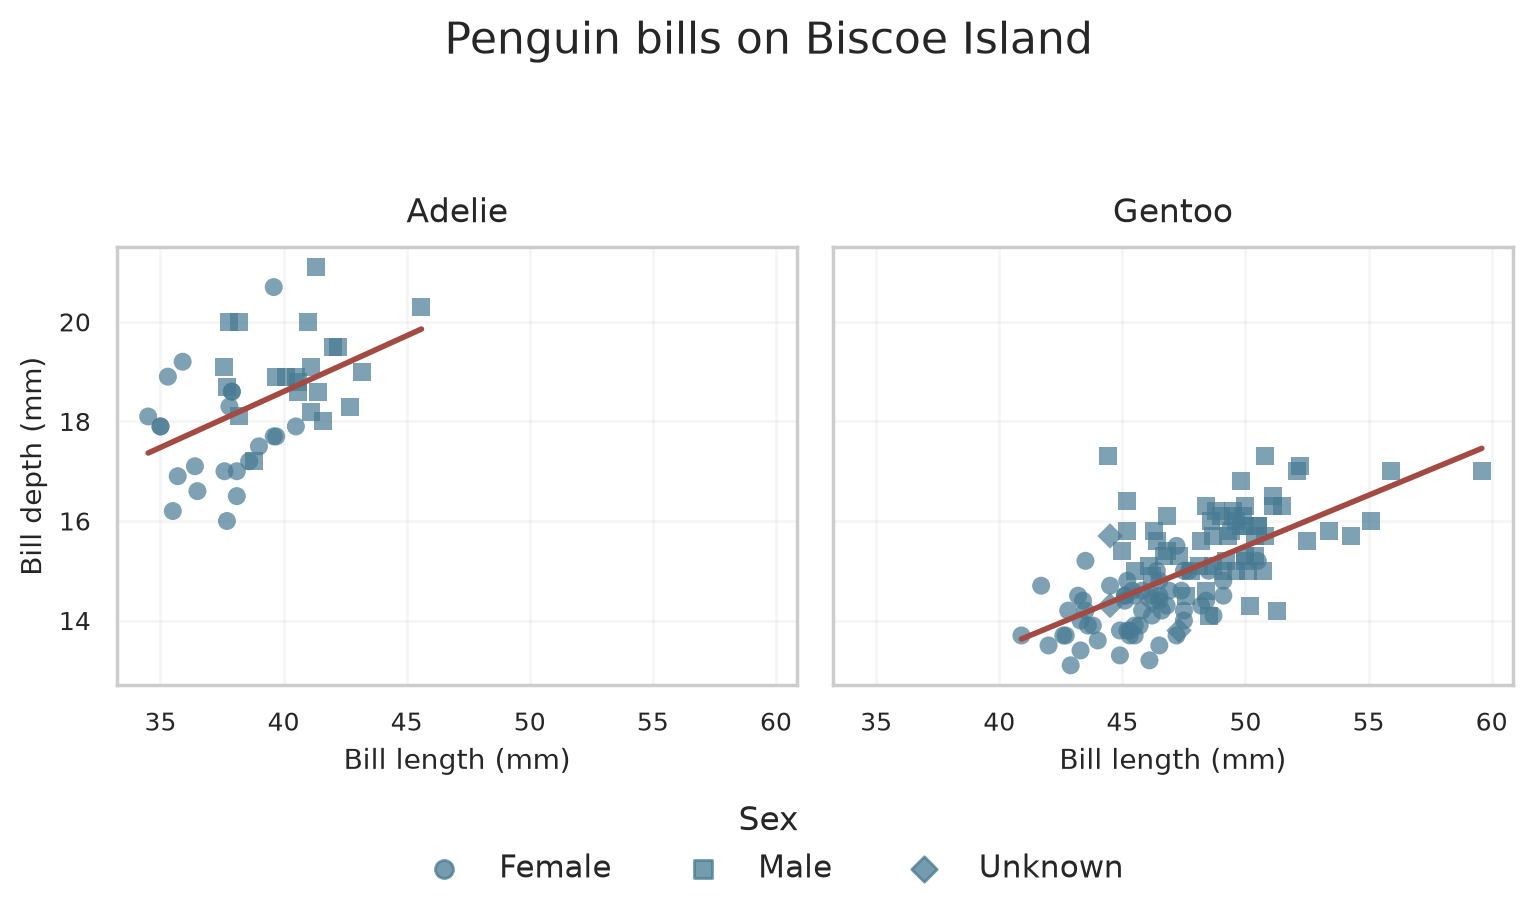

Augplot(backend='seaborn', state='fitted')

In [7]:
biscoe_penguins = penguins[penguins["island"] == "Biscoe"]
plt.render(biscoe_penguins, title="Penguin bills on Biscoe Island")

## 6. Save the chart as ordinary Python

Export the plotting function to `augplot_utils.py` and call it directly on the Biscoe subset.


In [8]:
plt.to_python(function_name="plot_penguin_bills")

# With '.' on your Python import path:
from augplot_utils import plot_penguin_bills
fig = plot_penguin_bills(your_data)
fig


PosixPath('augplot_utils.py')

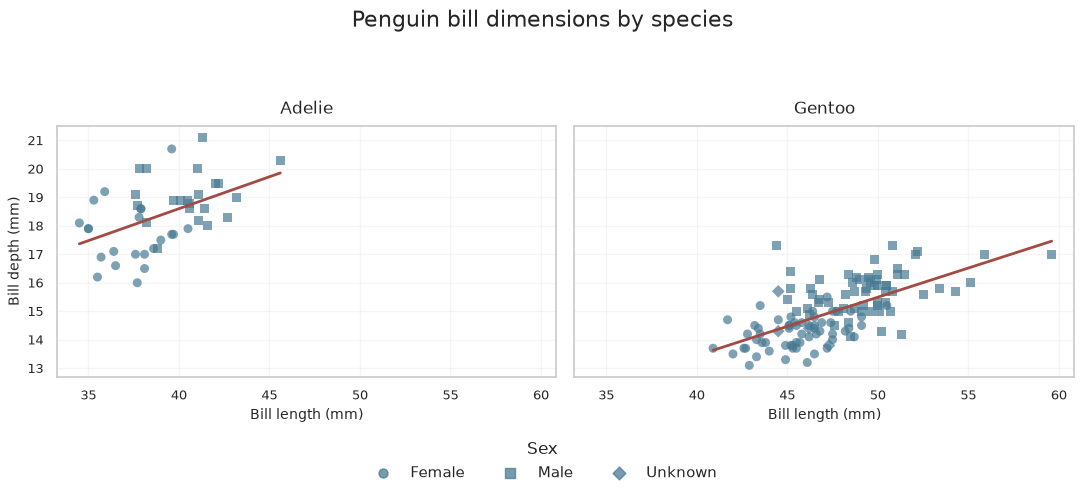

In [9]:
from augplot_utils import plot_penguin_bills

fig = plot_penguin_bills(biscoe_penguins, figsize=(11, 5))
fig

## 7. Change the question: reveal seasonality

Load the flights dataset and plot monthly passenger totals with one line per year.


Augplot: plotting... attempt 1/2
Augplot: checking generated plotting code...


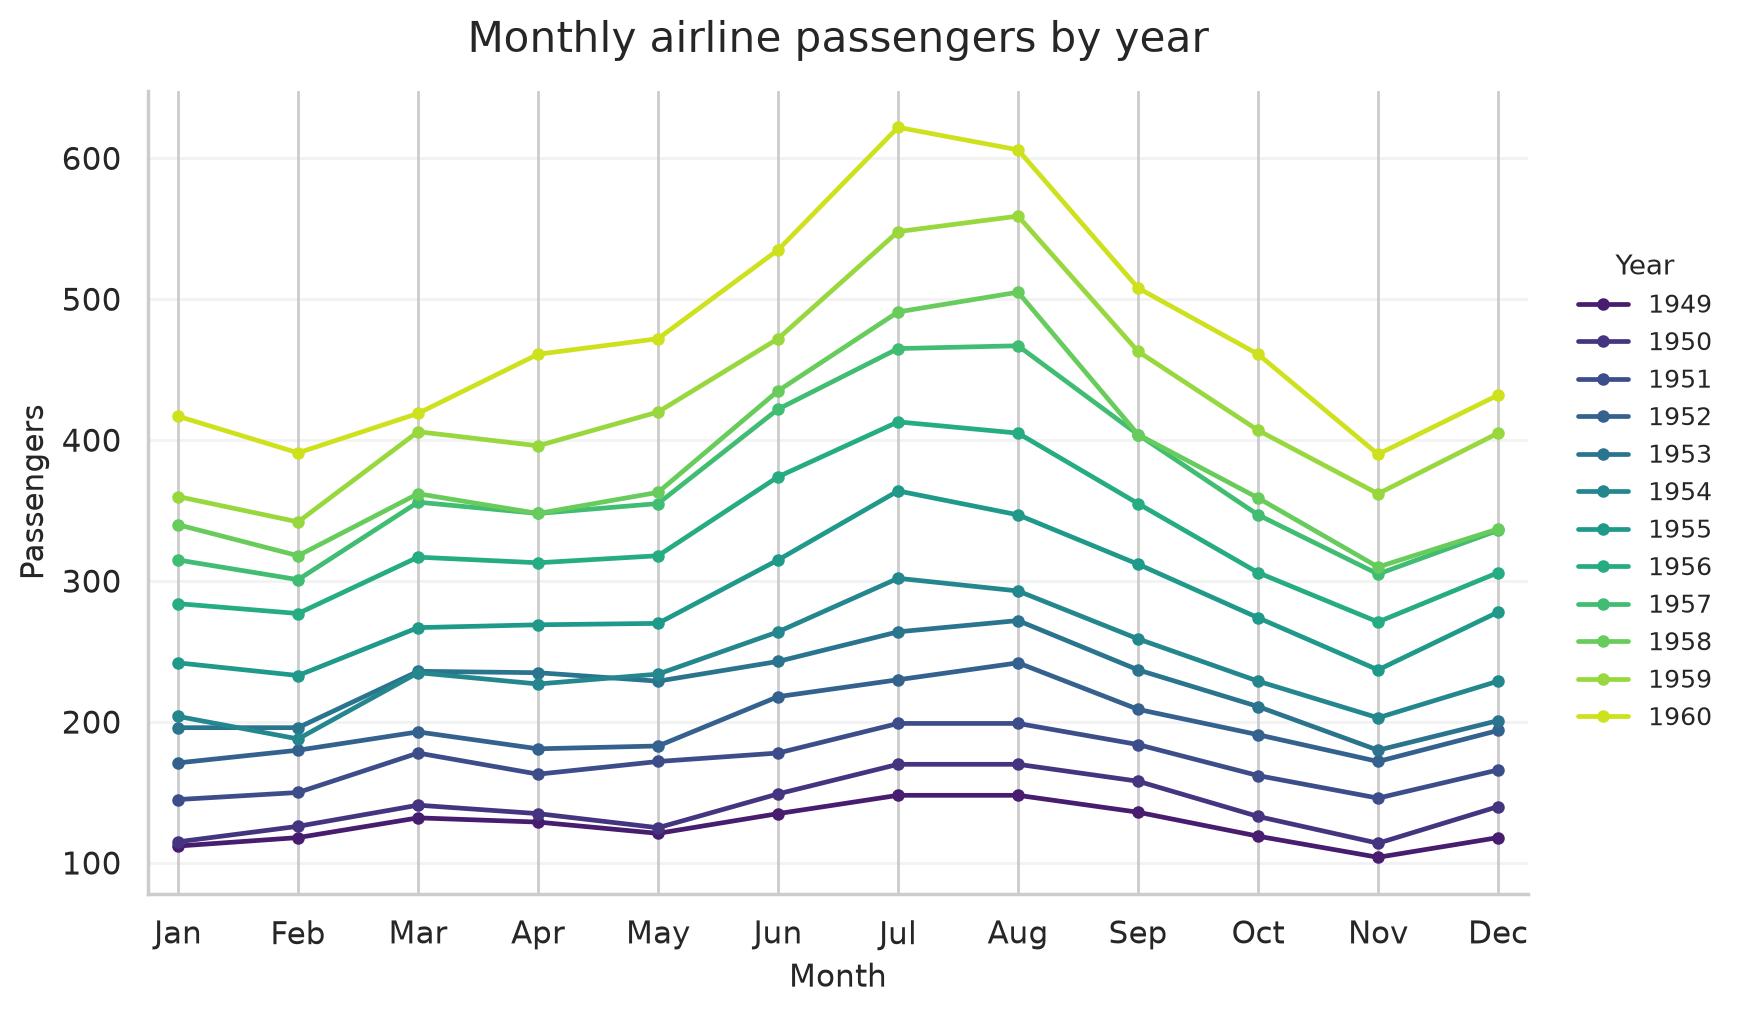

In [10]:
flights = ap.load_sns_dataset("flights")
flight_viz = ap.plot(
    flights,
    backend="seaborn",
    prompt="Plot monthly airline passengers over time, with one line per year.",
)

## 8. Reframe the same data as a seasonal heatmap

Refine the flights chart into an annotated year-by-month heatmap that highlights the busiest month.


Augplot: plotting... attempt 1/2
Augplot: still waiting for the model (attempt 1/2)...
Augplot: checking generated plotting code...


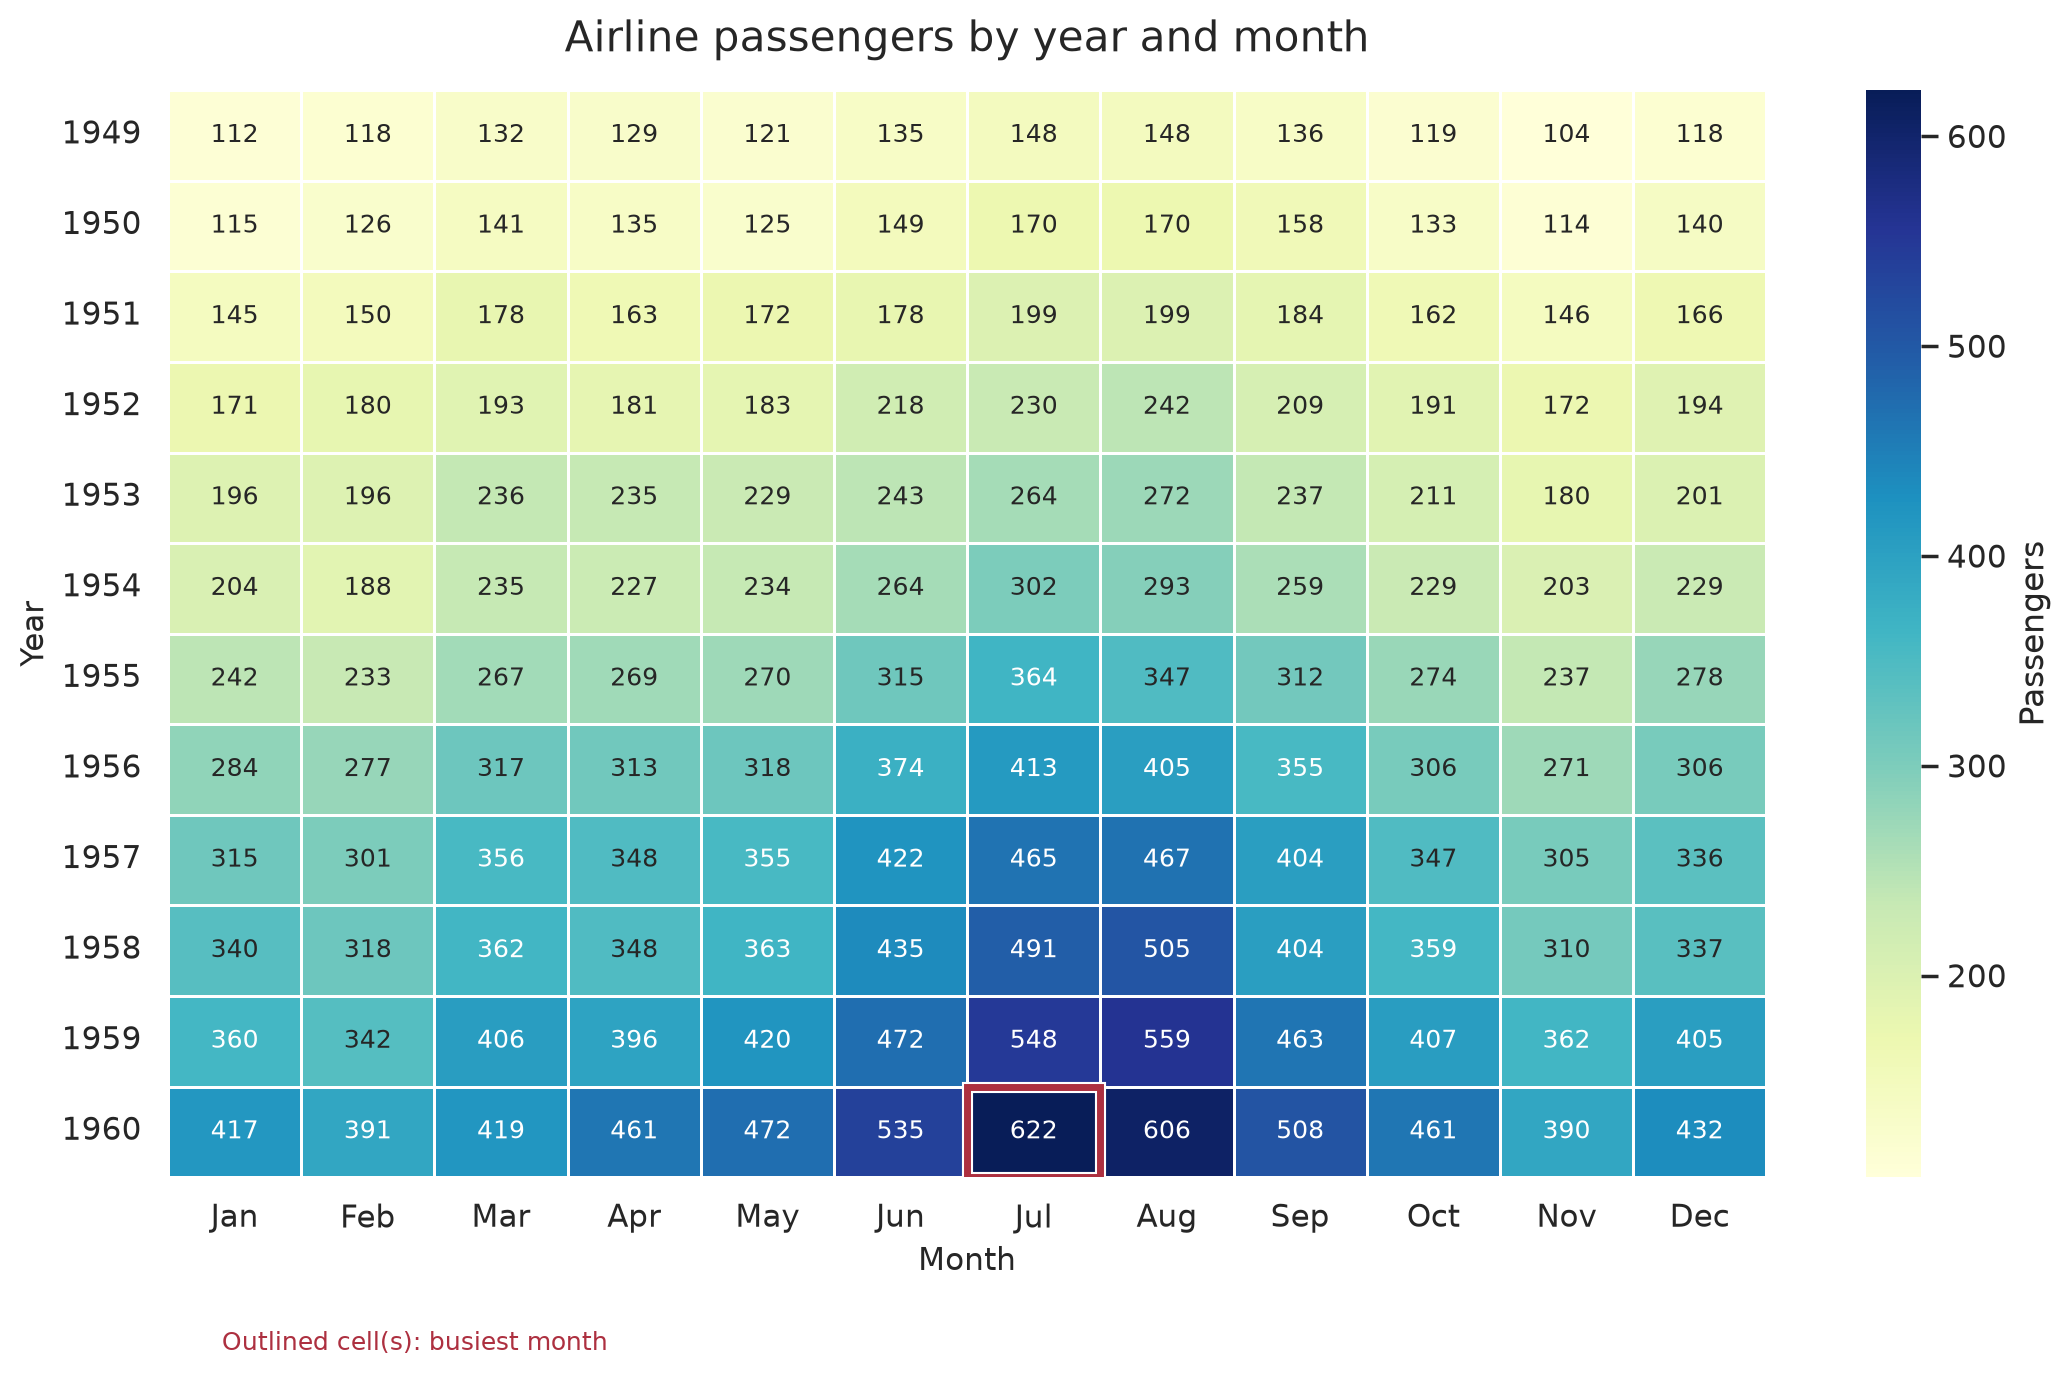

Augplot(backend='seaborn', state='fitted')

In [11]:
flight_viz.refine(
    "Turn this into a year-by-month heatmap, preserve calendar month order, "
    "annotate each cell, and emphasize the busiest month."
)

**Next:** See [visualization history](../docs/visualization-history.md) for replay, branching, and keeping saved charts with the notebook.
